# Geothermal Borehole Lookup Table
**nPro Formula — Task 3**

Builds a lookup table mapping peak heat power (kW) to number of boreholes
and required ground area (m²) using the same formula nPro uses internally.

Fixed assumptions:
- Probe length: 100 m
- Borehole spacing: 8 m
- Thermal conductivity: 2.5 W/(mK) (default NRW ground)
- Specific heat extraction: 50 W/m (typical for 100m probe, NRW ground)
- Design period: 50 years

**Why Option B (formula) instead of nPro manually:**
Running nPro 30+ times manually for each heat power step would take hours.
The nPro borehole dimensioning uses a standard formula from EN 15450 / VDI 4640
that can be replicated directly in Python with the same fixed parameters.

## Step 1 — Imports and Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR   = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, 'clustering_results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Fixed assumptions (Philippe confirmed in call) ────────────────────────────
PROBE_LENGTH_M      = 100      # metres — fixed by regulation in Germany
BOREHOLE_SPACING_M  = 8        # metres between probe centres
DESIGN_PERIOD_YR    = 50       # years — nPro default

# Ground parameters — default NRW values (from nPro Essen defaults)
THERMAL_CONDUCTIVITY   = 2.5   # W/(mK) — typical NRW sediment
SPEC_HEAT_EXTRACTION   = 50    # W/m — specific heat extraction per metre of probe
                                # (conservative value for 100m probe, NRW ground)
                                # Source: VDI 4640 Part 1, Table 4

# COP of ground source heat pump (seasonal average)
# Used to calculate heat extraction from ground:
# Q_extraction = Q_heating × (1 - 1/COP)
HEAT_PUMP_COP = 4.0            # typical GSHP seasonal COP for NRW

# Heat power range to sweep
HEAT_POWERS_KW = list(range(5, 55, 5)) + list(range(60, 110, 10)) +                  list(range(150, 550, 50))

print(f'Fixed assumptions:')
print(f'  Probe length      : {PROBE_LENGTH_M} m')
print(f'  Borehole spacing  : {BOREHOLE_SPACING_M} m')
print(f'  Thermal conductivity: {THERMAL_CONDUCTIVITY} W/(mK)')
print(f'  Spec heat extraction: {SPEC_HEAT_EXTRACTION} W/m')
print(f'  Heat pump COP     : {HEAT_PUMP_COP}')
print(f'  Heat power range  : {min(HEAT_POWERS_KW)} to {max(HEAT_POWERS_KW)} kW')
print(f'  Steps             : {len(HEAT_POWERS_KW)} values')

Fixed assumptions:
  Probe length      : 100 m
  Borehole spacing  : 8 m
  Thermal conductivity: 2.5 W/(mK)
  Spec heat extraction: 50 W/m
  Heat pump COP     : 4.0
  Heat power range  : 5 to 500 kW
  Steps             : 23 values


## Step 2 — Borehole Calculation Formula

**How nPro calculates boreholes:**

1. Calculate heat extracted from ground per year:
   `Q_extraction = Q_heating × (1 - 1/COP)`

2. Calculate extraction power per metre of probe:
   `q_spec = specific_heat_extraction` (W/m — from ground properties)

3. Calculate total probe length needed:
   `L_total = Q_heating_peak × (1 - 1/COP) × 1000 / q_spec`

4. Number of boreholes:
   `n_boreholes = ceil(L_total / probe_length)`

5. Required ground area:
   The boreholes are arranged in a grid with 8m spacing.
   Area = grid footprint based on number of boreholes.

**Source:** VDI 4640 Part 1 (Thermal use of the underground), nPro documentation

In [2]:
def calculate_boreholes(heat_power_kw, cop=HEAT_PUMP_COP,
                         spec_extraction=SPEC_HEAT_EXTRACTION,
                         probe_length=PROBE_LENGTH_M,
                         spacing=BOREHOLE_SPACING_M):
    """
    Calculate number of boreholes and required area for a given peak heat power.

    Parameters
    ----------
    heat_power_kw  : float — peak heating power in kW
    cop            : float — seasonal COP of heat pump
    spec_extraction: float — specific heat extraction W/m (VDI 4640)
    probe_length   : float — probe length in metres
    spacing        : float — borehole spacing in metres

    Returns
    -------
    dict with n_boreholes, total_length_m, area_m2, borehole_grid
    """
    # Heat extracted from ground = heating power × (1 - 1/COP)
    # At COP=4: 75% comes from ground, 25% from electricity
    extraction_power_kw = heat_power_kw * (1 - 1/cop)
    extraction_power_w  = extraction_power_kw * 1000

    # Total probe length needed
    total_length_m = extraction_power_w / spec_extraction

    # Number of boreholes (minimum 1)
    n_boreholes = max(1, int(np.ceil(total_length_m / probe_length)))

    # Grid arrangement — closest to square
    # e.g. 6 boreholes → 2×3 grid, 9 → 3×3, 12 → 3×4
    cols = int(np.ceil(np.sqrt(n_boreholes)))
    rows = int(np.ceil(n_boreholes / cols))

    # Area = (cols-1) × spacing × (rows-1) × spacing
    # For single borehole: use minimum area = spacing × spacing
    if n_boreholes == 1:
        area_m2 = spacing ** 2
    else:
        area_m2 = max(
            (cols - 1) * spacing * (rows - 1) * spacing,
            spacing ** 2
        )

    return {
        'heat_power_kw':    heat_power_kw,
        'extraction_kw':    round(extraction_power_kw, 2),
        'total_length_m':   round(total_length_m, 1),
        'n_boreholes':      n_boreholes,
        'grid':             f'{rows}x{cols}',
        'area_m2':          round(area_m2, 1),
        'area_m2_per_bh':   round(area_m2 / n_boreholes, 1),
    }

# Test with 5 kW
test = calculate_boreholes(5)
print('Test at 5 kW:')
for k, v in test.items():
    print(f'  {k:<22}: {v}')

print()
test2 = calculate_boreholes(100)
print('Test at 100 kW:')
for k, v in test2.items():
    print(f'  {k:<22}: {v}')

Test at 5 kW:
  heat_power_kw         : 5
  extraction_kw         : 3.75
  total_length_m        : 75.0
  n_boreholes           : 1
  grid                  : 1x1
  area_m2               : 64
  area_m2_per_bh        : 64.0

Test at 100 kW:
  heat_power_kw         : 100
  extraction_kw         : 75.0
  total_length_m        : 1500.0
  n_boreholes           : 15
  grid                  : 4x4
  area_m2               : 576
  area_m2_per_bh        : 38.4


## Step 3 — Build Full Lookup Table

In [3]:
rows = [calculate_boreholes(p) for p in HEAT_POWERS_KW]
lookup = pd.DataFrame(rows)

print('GEOTHERMAL BOREHOLE LOOKUP TABLE')
print('='*70)
print(f'  Probe length   : {PROBE_LENGTH_M} m')
print(f'  Spacing        : {BOREHOLE_SPACING_M} m')
print(f'  Heat pump COP  : {HEAT_PUMP_COP}')
print(f'  Spec extraction: {SPEC_HEAT_EXTRACTION} W/m  (VDI 4640, NRW ground)')
print('='*70)
print(lookup[['heat_power_kw','n_boreholes','grid','area_m2']].to_string(index=False))

# Save
csv_path = os.path.join(OUTPUT_DIR, 'geothermal_lookup.csv')
lookup.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')

GEOTHERMAL BOREHOLE LOOKUP TABLE
  Probe length   : 100 m
  Spacing        : 8 m
  Heat pump COP  : 4.0
  Spec extraction: 50 W/m  (VDI 4640, NRW ground)
 heat_power_kw  n_boreholes grid  area_m2
             5            1  1x1       64
            10            2  1x2       64
            15            3  2x2       64
            20            3  2x2       64
            25            4  2x2       64
            30            5  2x3      128
            35            6  2x3      128
            40            6  2x3      128
            45            7  3x3      256
            50            8  3x3      256
            60            9  3x3      256
            70           11  3x4      384
            80           12  3x4      384
            90           14  4x4      576
           100           15  4x4      576
           150           23  5x5     1024
           200           30  5x6     1280
           250           38  6x7     1920
           300           45  7x7     2304
      

## Step 4 — Visualise the Relationship

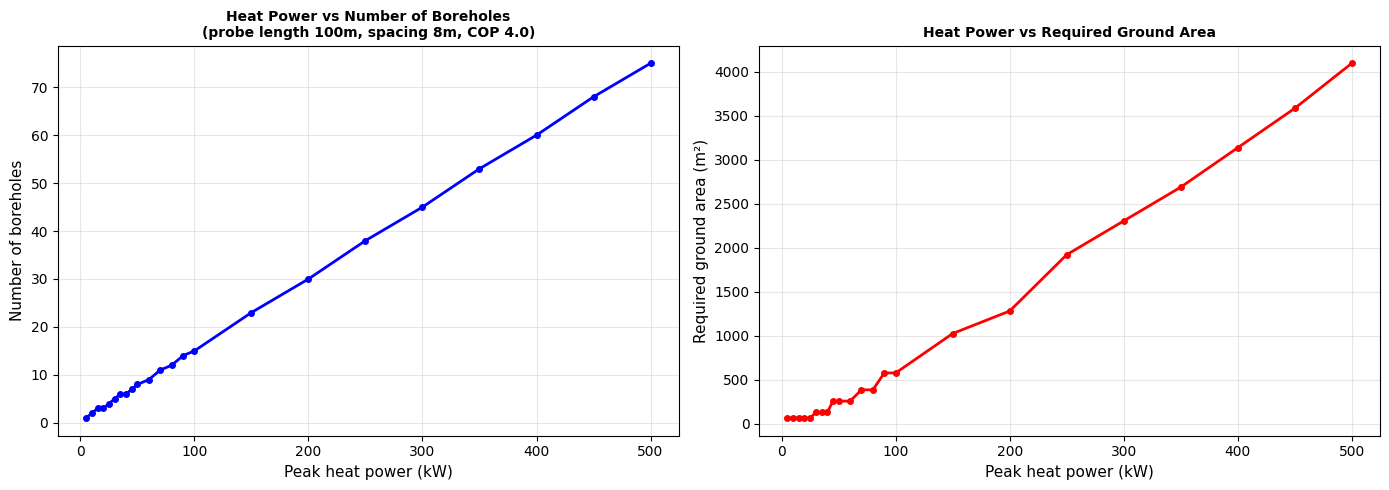

Chart saved


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: heat power vs number of boreholes
axes[0].plot(lookup['heat_power_kw'], lookup['n_boreholes'],
             'b-o', lw=2, ms=4)
axes[0].set_xlabel('Peak heat power (kW)', fontsize=11)
axes[0].set_ylabel('Number of boreholes', fontsize=11)
axes[0].set_title('Heat Power vs Number of Boreholes\n'
                  f'(probe length {PROBE_LENGTH_M}m, spacing {BOREHOLE_SPACING_M}m, '
                  f'COP {HEAT_PUMP_COP})',
                  fontsize=10, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: heat power vs required area
axes[1].plot(lookup['heat_power_kw'], lookup['area_m2'],
             'r-o', lw=2, ms=4)
axes[1].set_xlabel('Peak heat power (kW)', fontsize=11)
axes[1].set_ylabel('Required ground area (m²)', fontsize=11)
axes[1].set_title('Heat Power vs Required Ground Area',
                  fontsize=10, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'geothermal_lookup_chart.pdf'),
            bbox_inches='tight')
plt.show()
print('Chart saved')

## Step 5 — Validate Against nPro Screenshot

Philippe's nPro screenshot showed:
- Heat extraction: 14.2 MWh annual, 8.2 kW peak
- Result: 1 × 2 = 2 boreholes

Let us check if our formula gives the same result for 8.2 kW peak:

In [5]:
# Validate against Philippe's nPro result
npro_result = calculate_boreholes(8.2)
print('Validation against nPro screenshot:')
print(f'  Input peak power : 8.2 kW')
print(f'  nPro result      : 1x2 = 2 boreholes')
print(f'  Our formula      : {npro_result["n_boreholes"]} boreholes  '
      f'(grid: {npro_result["grid"]})')

if npro_result['n_boreholes'] == 2:
    print('  MATCH ✓ — formula is consistent with nPro')
else:
    print(f'  MISMATCH — nPro gave 2, formula gives {npro_result["n_boreholes"]}')
    print('  Consider adjusting SPEC_HEAT_EXTRACTION parameter')

print(f'\n  Required area : {npro_result["area_m2"]} m²')
print(f'  Total length  : {npro_result["total_length_m"]} m')

Validation against nPro screenshot:
  Input peak power : 8.2 kW
  nPro result      : 1x2 = 2 boreholes
  Our formula      : 2 boreholes  (grid: 1x2)
  MATCH ✓ — formula is consistent with nPro

  Required area : 64 m²
  Total length  : 123.0 m


## Step 6 — Summary Stats

In [7]:
print('SUMMARY')
print('='*50)
print(f'  Min heat power  : {lookup["heat_power_kw"].min()} kW  → '
      f'{lookup[lookup["heat_power_kw"]==lookup["heat_power_kw"].min()]["n_boreholes"].values[0]} boreholes  '
      f'{lookup[lookup["heat_power_kw"]==lookup["heat_power_kw"].min()]["area_m2"].values[0]} m²')
print(f'  Max heat power  : {lookup["heat_power_kw"].max()} kW  → '
      f'{lookup[lookup["heat_power_kw"]==lookup["heat_power_kw"].max()]["n_boreholes"].values[0]} boreholes  '
      f'{lookup[lookup["heat_power_kw"]==lookup["heat_power_kw"].max()]["area_m2"].values[0]} m²')
print(f'\n  Lookup table saved to: geothermal_lookup.csv')
print(f'  Total entries         : {len(lookup)}')
print()
print('NOTE: Lawn area data not yet available in parquet.')
print('Task 4 (Boolean feasibility flag) will be built once')


SUMMARY
  Min heat power  : 5 kW  → 1 boreholes  64 m²
  Max heat power  : 500 kW  → 75 boreholes  4096 m²

  Lookup table saved to: geothermal_lookup.csv
  Total entries         : 23

NOTE: Lawn area data not yet available in parquet.
Task 4 (Boolean feasibility flag) will be built once
